   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payment Method  Monthly Charges Tota

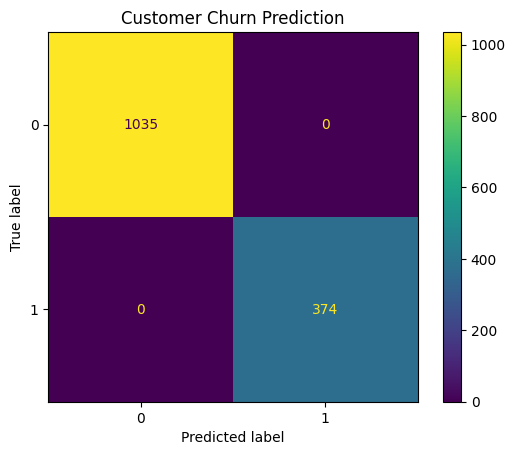

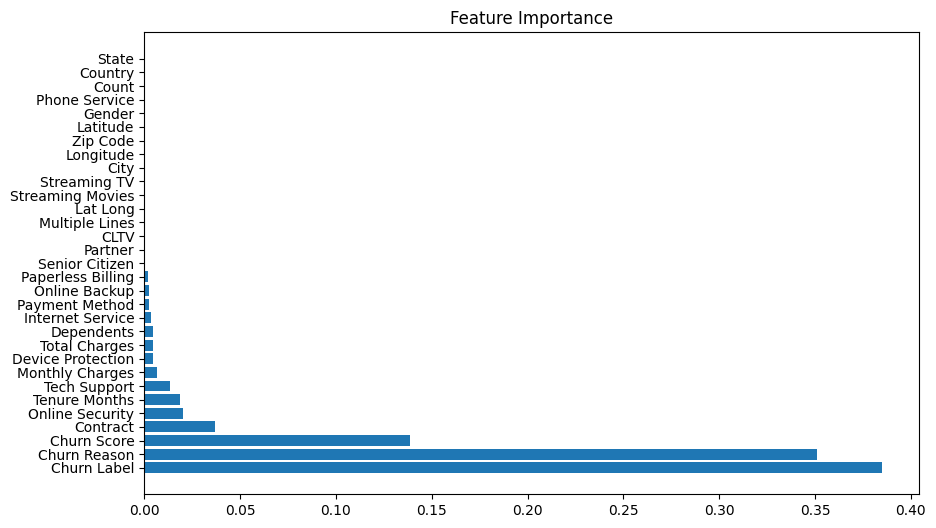


Model saved successfully.


In [8]:
# ==========================================
# CUSTOMER CHURN PREDICTION
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib



In [9]:
# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_excel("/content/sample_data/Telco_customer_churn.xlsx")

print(df.head())
print(df.info())


   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payment Method  Monthly Charges Tota

In [10]:
# ==========================================
# DATA CLEANING
# ==========================================

df.drop("CustomerID", axis=1, inplace=True)

df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

df.fillna(df.median(numeric_only=True),
          inplace=True)



In [11]:
# ==========================================
# ENCODE CATEGORICAL FEATURES
# ==========================================

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])


In [12]:
# ==========================================
# FEATURES & TARGET
# ==========================================

X = df.drop("Churn Value", axis=1)
y = df["Churn Value"]



In [13]:
# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [14]:

# ==========================================
# SCALING
# ==========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [15]:
# ==========================================
# RANDOM FOREST
# ==========================================

rf = RandomForestClassifier(
    random_state=42
)

params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    rf,
    params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:")
print(grid.best_params_)



Best Parameters:
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}


In [16]:
# ==========================================
# PREDICTION
# ==========================================

y_pred = best_model.predict(X_test)



In [17]:
# ==========================================}
# EVALUATION
# ==========================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nAccuracy:", accuracy)

print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred
    )
)



Accuracy: 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1035
           1       1.00      1.00      1.00       374

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



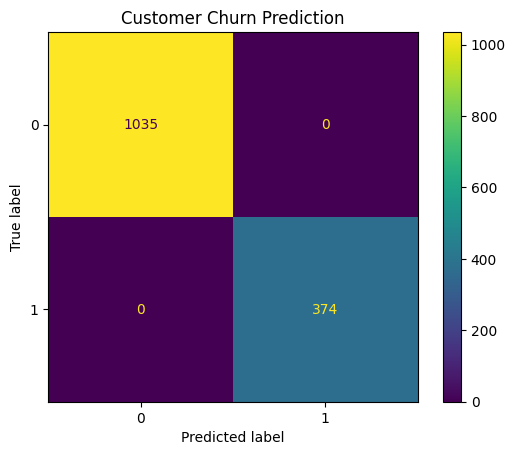

In [18]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "Customer Churn Prediction"
)

plt.show()



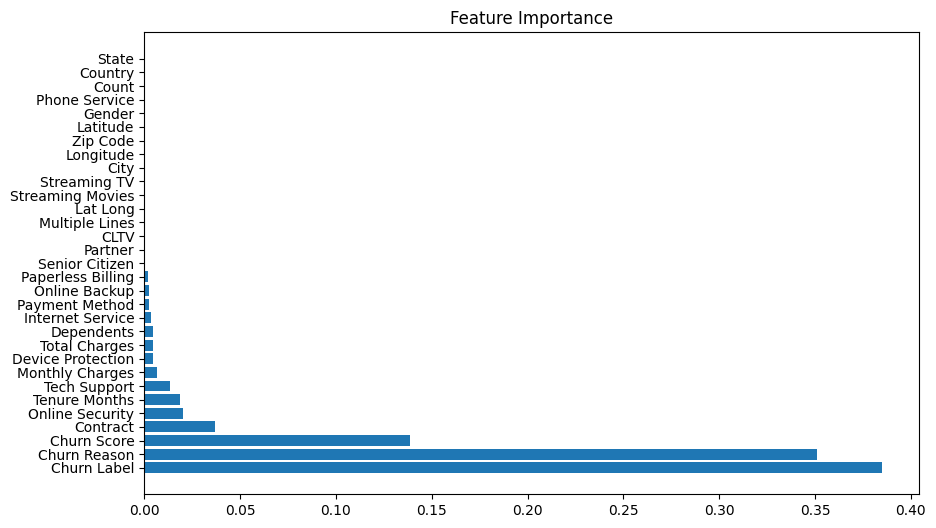

In [19]:
# ==========================================
# FEATURE IMPORTANCE
# ==========================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance":
    best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title(
    "Feature Importance"
)

plt.show()



In [20]:
# ==========================================
# SAVE MODEL
# ==========================================

joblib.dump(
    best_model,
    "churn_model.pkl"
)

print(
    "\nModel saved successfully."
)


Model saved successfully.
